In [55]:
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Dict, Any
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

In [22]:
mpl.rcParams['font.family'] = 'Nimbus Roman'
plt.rcParams['font.size'] = 15

In [3]:
def df_to_bin_tensors(df: pd.DataFrame, max_particles: int = 200) -> Tuple[torch.LongTensor, torch.LongTensor, torch.LongTensor, torch.LongTensor]:
    """
    Liefert pT, eta, phi Tensors (B, N) mit -1 als Padding, auf CPU (nicht auf device).
    Effizientere Implementation: nur vorhandene Spalten werden genutzt.
    """
    pattern = re.compile(r'^(pT|eta|phi)_bin_(\d+)$')
    present_idxs = set()
    for col in df.columns:
        m = pattern.match(col)
        if m:
            present_idxs.add(int(m.group(2)))
    max_present = max(present_idxs) if present_idxs else -1

    B = len(df)
    N = max_particles

    pT_arr = np.full((B, N), -1, dtype=np.int64)
    eta_arr = np.full((B, N), -1, dtype=np.int64)
    phi_arr = np.full((B, N), -1, dtype=np.int64)

    for j in sorted(present_idxs):
        if j >= N:
            break
        pt_col = f"pT_bin_{j}"
        if pt_col in df.columns:
            pT_arr[:, j] = df[pt_col].fillna(-1).astype(np.int64).values
        eta_col = f"eta_bin_{j}"
        if eta_col in df.columns:
            eta_arr[:, j] = df[eta_col].fillna(-1).astype(np.int64).values
        phi_col = f"phi_bin_{j}"
        if phi_col in df.columns:
            phi_arr[:, j] = df[phi_col].fillna(-1).astype(np.int64).values

    if max_present >= 0:
        available = [f"pT_bin_{j}" for j in range(min(max_present + 1, N)) if f"pT_bin_{j}" in df.columns]
        if available:
            stacked = np.stack([df[c].fillna(-1).astype(np.int64).values for c in available], axis=1)  # (B, M)
            counts = np.sum(stacked != -1, axis=1).astype(np.int64)
        else:
            counts = np.zeros(B, dtype=np.int64)
    else:
        counts = np.zeros(B, dtype=np.int64)

    counts = np.minimum(counts, N)

    pT_t = torch.from_numpy(pT_arr).long()   # CPU tensor
    eta_t = torch.from_numpy(eta_arr).long()
    phi_t = torch.from_numpy(phi_arr).long()
    counts_t = torch.from_numpy(counts).long()

    return pT_t, eta_t, phi_t, counts_t

class ParticleEmbedder(nn.Module):
    def __init__(self,
                 emb_dim: int = 256,
                 pT_max_value: int = 40,
                 eta_max_value: int = 30,
                 phi_max_value: int = 30,
                 max_particles: int = 100,
                 use_position_embedding: bool = False,
                 dropout: float = 0.0):
        super().__init__()
        self.emb_dim = emb_dim
        self.max_particles = max_particles
        self.S = 1 + max_particles + 1  # START + N + STOP

        self.pT_emb = nn.Embedding(num_embeddings=pT_max_value + 2, embedding_dim=emb_dim, padding_idx=0)
        self.eta_emb = nn.Embedding(num_embeddings=eta_max_value + 2, embedding_dim=emb_dim, padding_idx=0)
        self.phi_emb = nn.Embedding(num_embeddings=phi_max_value + 2, embedding_dim=emb_dim, padding_idx=0)

        self.use_position_embedding = use_position_embedding
        if use_position_embedding:
            self.pos_emb = nn.Embedding(max_particles + 1, emb_dim)
            pos_idx = torch.arange(1, max_particles + 1).unsqueeze(0)  # (1, N)
            self.register_buffer("pos_idx_buffer", pos_idx, persistent=False)
        else:
            self.pos_emb = None
            self.register_buffer("pos_idx_buffer", torch.empty(0), persistent=False)

        self.start_token = nn.Parameter(torch.randn(emb_dim) * 0.02)
        self.stop_token = nn.Parameter(torch.randn(emb_dim) * 0.02)

        self.layernorm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

    def forward(self, pT_bins: torch.LongTensor, eta_bins: torch.LongTensor, phi_bins: torch.LongTensor, counts: torch.LongTensor) -> torch.FloatTensor:
        B, N = pT_bins.shape
        assert N == self.max_particles
        device = pT_bins.device
        D = self.emb_dim
        S = self.S

        pT_idx = torch.clamp(pT_bins + 1, min=0, max=self.pT_emb.num_embeddings - 1)
        eta_idx = torch.clamp(eta_bins + 1, min=0, max=self.eta_emb.num_embeddings - 1)
        phi_idx = torch.clamp(phi_bins + 1, min=0, max=self.phi_emb.num_embeddings - 1)

        e_pT = self.pT_emb(pT_idx)
        e_eta = self.eta_emb(eta_idx)
        e_phi = self.phi_emb(phi_idx)
        e_particles = e_pT + e_eta + e_phi

        if self.use_position_embedding:
            pos_idx = self.pos_idx_buffer.to(device).expand(B, N)  # (B,N)
            e_particles = e_particles + self.pos_emb(pos_idx)

        seq = torch.zeros((B, S, D), dtype=e_particles.dtype, device=device)
        seq[:, 0, :] = self.start_token.view(1, D)

        arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
        counts_exp = counts.unsqueeze(1).expand(B, N)
        shift = (arange >= counts_exp).long()
        dest = 1 + arange + shift  # (B, N)

        dest_idx = dest.unsqueeze(-1).expand(B, N, D)
        seq = seq.scatter(dim=1, index=dest_idx, src=e_particles)

        stop_needed = (counts < N)
        if stop_needed.any():
            stop_pos = (1 + counts).to(torch.long)
            batch_idx = torch.arange(B, device=device)
            seq[batch_idx[stop_needed], stop_pos[stop_needed], :] = self.stop_token.view(1, D)

        seq = self.layernorm(seq)
        seq = self.dropout(seq)
        return seq

    def make_masks(self, pT_bins: torch.LongTensor, counts: torch.LongTensor) -> Tuple[torch.BoolTensor, torch.BoolTensor]:
        B, N = pT_bins.shape
        device = pT_bins.device
        S = self.S

        orig_pad = (pT_bins == -1)
        arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
        counts_exp = counts.unsqueeze(1).expand(B, N)
        shift = (arange >= counts_exp).long()
        dest = 1 + arange + shift

        src_key_padding_mask = torch.ones((B, S), dtype=torch.bool, device=device)
        src_key_padding_mask[:, 0] = False  # START unmasked

        batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(B, N)
        real_mask = ~orig_pad
        if real_mask.any():
            src_key_padding_mask[batch_idx[real_mask], dest[real_mask]] = False

        stop_needed = (counts < N)
        if stop_needed.any():
            stop_pos = (1 + counts)
            batch_idx_simple = torch.arange(B, device=device)
            src_key_padding_mask[batch_idx_simple[stop_needed], stop_pos[stop_needed]] = False

        causal_mask = torch.triu(torch.ones((S, S), dtype=torch.bool, device=device), diagonal=0)
        causal_mask[:, 0] = False
        causal_mask[0, 0] = False

        return src_key_padding_mask, causal_mask

class ParticleTransformer(nn.Module):
    def __init__(self,
                 num_pT_embeddings: int = 42,
                 num_eta_embeddings: int = 32,
                 num_phi_embeddings: int = 32,
                 emb_dim: int = 256,
                 n_layers: int = 8,
                 n_heads: int = 4,
                 dim_feedforward: int = None,
                 dropout: float = 0.1,
                 pad_token: int = 0):
        super().__init__()
        self.emb_dim = emb_dim
        self.pad_token = pad_token
        if dim_feedforward is None:
            dim_feedforward = emb_dim * 4

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim,
                                                   nhead=n_heads,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout,
                                                   activation='relu',
                                                   batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, norm=nn.LayerNorm(emb_dim))

        self.final_norm = nn.LayerNorm(emb_dim)
        self.final_dropout = nn.Dropout(dropout)

        self.type_head = nn.Linear(emb_dim, 3)
        self.head_pT  = nn.Linear(emb_dim, num_pT_embeddings)
        self.head_eta = nn.Linear(emb_dim, num_eta_embeddings)
        self.head_phi = nn.Linear(emb_dim, num_phi_embeddings)

    def forward(self, seq_emb: torch.FloatTensor, src_key_padding_mask: torch.BoolTensor, causal_mask: torch.BoolTensor):
        B, S, D = seq_emb.shape
        assert D == self.emb_dim

        attn_mask = None
        if causal_mask is not None:
            attn_mask = causal_mask
            if attn_mask.dtype != torch.bool:
                attn_mask = attn_mask.bool()
            assert attn_mask.shape == (S, S)

        enc = self.encoder(seq_emb, mask=attn_mask, src_key_padding_mask=src_key_padding_mask)
        enc = self.final_norm(enc)
        enc = self.final_dropout(enc)

        logits_type = self.type_head(enc)
        logits_pT  = self.head_pT(enc)
        logits_eta = self.head_eta(enc)
        logits_phi = self.head_phi(enc)

        return logits_type, logits_pT, logits_eta, logits_phi

# ---------------------------
# Hilfsfunktionen zum Laden des Checkpoints & Modellerstellung
# ---------------------------
def load_checkpoint_maybe_with_config(path: str, device: torch.device) -> Dict[str, Any]:
    """
    Lädt ein .pt-File und versucht, entweder:
      - direkt ein state_dict zu liefern (-> returns {"state_dict": ...})
      - oder ein checkpoint dict mit keys like 'model_state_dict' und 'config'
    """
    ckpt = torch.load(path, map_location=device)
    # flexible handling
    if isinstance(ckpt, dict):
        # if it looks like a model state dict already
        if 'model_state_dict' in ckpt or 'state_dict' in ckpt or 'config' in ckpt:
            return ckpt
        else:
            # maybe the user saved state_dict directly
            return {'model_state_dict': ckpt}
    else:
        # e.g. saved as state_dict tensor store
        return {'model_state_dict': ckpt}


def build_models_from_config(config: Dict[str, Any]) -> Tuple[ParticleEmbedder, ParticleTransformer]:
    """
    Erzeugt embedder und transformer aus einem config-dict.
    Erwartete keys (falls nicht vorhanden, werden Defaultwerte genutzt):
      - emb_dim, pT_max, eta_max, phi_max, max_particles, use_position_embedding, dropout
      - num_pT_embeddings, num_eta_embeddings, num_phi_embeddings, n_layers, n_heads, dim_feedforward
    """
    emb_conf = {
        'emb_dim': config.get('emb_dim', 256),
        'pT_max_value': config.get('pT_max_value', config.get('num_pT_embeddings', 40)),
        'eta_max_value': config.get('eta_max_value', config.get('num_eta_embeddings', 30)),
        'phi_max_value': config.get('phi_max_value', config.get('num_phi_embeddings', 30)),
        'max_particles': config.get('max_particles', 100),
        'use_position_embedding': config.get('use_position_embedding', False),
        'dropout': config.get('dropout', 0.0)
    }
    embedder = ParticleEmbedder(**emb_conf)

    trans_conf = {
        'num_pT_embeddings': config.get('num_pT_embeddings', 42),
        'num_eta_embeddings': config.get('num_eta_embeddings', 32),
        'num_phi_embeddings': config.get('num_phi_embeddings', 32),
        'emb_dim': config.get('emb_dim', 256),
        'n_layers': config.get('n_layers', 8),
        'n_heads': config.get('n_heads', 4),
        'dim_feedforward': config.get('dim_feedforward', None),
        'dropout': config.get('dropout', 0.1),
        'pad_token': config.get('pad_token', 0)
    }
    transformer = ParticleTransformer(**trans_conf)
    return embedder, transformer


def load_model_from_checkpoint(path: str, device: torch.device, config_override: Dict[str, Any] = None):
    ckpt = torch.load(
        path,
        map_location=device,
        weights_only=True
    )

    # determine config
    config = {}
    if 'config' in ckpt and isinstance(ckpt['config'], dict):
        config.update(ckpt['config'])
    if config_override:
        config.update(config_override)

    embedder, transformer = build_models_from_config(config)
    wrapper = nn.Module()
    # put both as attributes for easy loading
    wrapper.embedder = embedder
    wrapper.transformer = transformer

    # load weights: support both single state_dict or separate keys
    if 'model_state_dict' in ckpt:
        state = ckpt['model_state_dict']
    elif 'state_dict' in ckpt:
        state = ckpt['state_dict']
    else:
        # maybe user provided a raw state_dict
        state = ckpt

    # Try loading by splitting keys if checkpoint stored a flat dict with prefix
    try:
        wrapper_state = wrapper.state_dict()
        # align keys if prefixes exist
        # naive approach: if keys match directly -> load
        missing, unexpected = wrapper.load_state_dict(state, strict=False)
    except Exception as e:
        # fallback: try to load into embedder / transformer separately
        if 'embedder.' in list(state.keys())[0]:
            # state already prefixed
            wrapper.load_state_dict(state, strict=False)
        else:
            # try matching embedder and transformer prefixes
            s_embed = {k.replace('embedder.', ''): v for k, v in state.items() if k.startswith('embedder.')}
            s_trans = {k.replace('transformer.', ''): v for k, v in state.items() if k.startswith('transformer.')}
            if s_embed:
                embedder.load_state_dict(s_embed, strict=False)
            if s_trans:
                transformer.load_state_dict(s_trans, strict=False)
    wrapper.to(device)
    wrapper.eval()
    return wrapper, config


# ---------------------------
# Kern: Berechnung der Log-Wahrscheinlichkeit eines beobachteten Events
# ---------------------------
def compute_event_log_probs(wrapper: nn.Module,
                            pT_bins: torch.LongTensor,
                            eta_bins: torch.LongTensor,
                            phi_bins: torch.LongTensor,
                            counts: torch.LongTensor,
                            device: torch.device) -> Dict[str, torch.Tensor]:
    """
    Berechnet für jeden Batch-Eintrag die Log-Wahrscheinlichkeit des vollständigen Events,
    indem die modellierten bedingten Wahrscheinlichkeiten (type, pT, eta, phi) an den
    entsprechenden Positionen ausgewertet und aufsummiert werden (log-domain).

    Annahmen / Hinweise:
    - pT_bins, eta_bins, phi_bins haben shape (B, N) mit -1 für Padding.
    - counts hat shape (B,) mit Anzahl echter Teilchen pro Event (<= N).
    - Mapping für type_head: [0=start, 1=particle, 2=stop] (falls anders, anpassen!)
    - Wir summieren nur Beiträge an Positionen, die nicht von src_key_padding_mask maskiert sind.
    """
    embedder: ParticleEmbedder = wrapper.embedder
    transformer: ParticleTransformer = wrapper.transformer

    pT_bins = pT_bins.to(device)
    eta_bins = eta_bins.to(device)
    phi_bins = phi_bins.to(device)
    counts = counts.to(device)

    # 1) Erzeuge Sequenz-Embedding und Masken
    seq_emb = embedder(pT_bins, eta_bins, phi_bins, counts)  # (B, S, D)
    src_key_padding_mask, causal_mask = embedder.make_masks(pT_bins, counts)  # (B,S), (S,S)

    # 2) Forward durch Transformer
    with torch.no_grad():
        logits_type, logits_pT, logits_eta, logits_phi = transformer(seq_emb, src_key_padding_mask, causal_mask)
        # logits shapes:
        # logits_type: (B, S, 3)
        # logits_pT : (B, S, num_pT_embeddings)
        # logits_eta: (B, S, num_eta_embeddings)
        # logits_phi: (B, S, num_phi_embeddings)

    B, S, _ = logits_type.shape
    N = pT_bins.shape[1]

    # 3) Erzeuge Targets / Positionen (gleiche Logik wie embedder)
    arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
    counts_exp = counts.unsqueeze(1).expand(B, N)
    shift = (arange >= counts_exp).long()
    dest = 1 + arange + shift  # (B,N) - Positionen im Seq, an die die Teilchen-Embeddings gerutscht wurden

    # Masken
    is_particle_pos = torch.zeros((B, S), dtype=torch.bool, device=device)
    batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(B, N)
    real_mask = (pT_bins != -1)
    if real_mask.any():
        is_particle_pos[batch_idx[real_mask], dest[real_mask]] = True

    # stop positions (falls counts < N)
    stop_pos = (1 + counts).to(torch.long)  # (B,)
    is_stop_pos = torch.zeros((B, S), dtype=torch.bool, device=device)
    stop_needed = (counts < N)
    if stop_needed.any():
        batch_idx_simple = torch.arange(B, device=device)
        is_stop_pos[batch_idx_simple[stop_needed], stop_pos[stop_needed]] = True

    # start pos is pos 0
    is_start_pos = torch.zeros((B, S), dtype=torch.bool, device=device)
    is_start_pos[:, 0] = True

    # type targets: assume mapping 0=start, 1=particle, 2=stop
    target_type = torch.full((B, S), fill_value=0, dtype=torch.long, device=device)
    target_type[is_particle_pos] = 1
    target_type[is_stop_pos] = 2
    target_type[is_start_pos] = 0

    # For pT/eta/phi targets we need an index tensor aligned to S positions.
    # Initialize with 0 (padding index after +1): recall embedder used pT_idx = clamp(pT_bins+1,...)
    pT_target_seq = torch.zeros((B, S), dtype=torch.long, device=device)
    eta_target_seq = torch.zeros((B, S), dtype=torch.long, device=device)
    phi_target_seq = torch.zeros((B, S), dtype=torch.long, device=device)

    # fill targets at particle positions: use original bins + 1 (same mapping wie embedder)
    max_pT_idx = logits_pT.size(-1) - 1
    max_eta_idx = logits_eta.size(-1) - 1
    max_phi_idx = logits_phi.size(-1) - 1

    if real_mask.any():
        pT_vals = (pT_bins + 1).clamp(min=0, max=max_pT_idx).to(torch.long)
        eta_vals = (eta_bins + 1).clamp(min=0, max=max_eta_idx).to(torch.long)
        phi_vals = (phi_bins + 1).clamp(min=0, max=max_phi_idx).to(torch.long)

        pT_target_seq[batch_idx[real_mask], dest[real_mask]] = pT_vals[real_mask]
        eta_target_seq[batch_idx[real_mask], dest[real_mask]] = eta_vals[real_mask]
        phi_target_seq[batch_idx[real_mask], dest[real_mask]] = phi_vals[real_mask]

    # 4) log-softmax für alle heads
    logp_type = F.log_softmax(logits_type, dim=-1)    # (B,S,3)
    logp_pT   = F.log_softmax(logits_pT, dim=-1)     # (B,S,num_pT)
    logp_eta  = F.log_softmax(logits_eta, dim=-1)    # (B,S,num_eta)
    logp_phi  = F.log_softmax(logits_phi, dim=-1)    # (B,S,num_phi)

    # 5) Selektiere Wahrscheinlichkeiten an interessanten Positionen
    # type contributions: für alle nicht-maskierten Positionen (src_key_padding_mask == False)
    include_pos = ~src_key_padding_mask  # (B,S) True = tatsächliche token positions (start, particles, stop)
    # Gather type logprobs:
    type_lp = logp_type.gather(dim=2, index=target_type.unsqueeze(-1)).squeeze(-1)  # (B,S)
    type_lp = torch.where(include_pos, type_lp, torch.zeros_like(type_lp))  # nur einschließen wenn nicht masked

    # Für pT/eta/phi: nur particle positions tragen bei
    pT_lp = logp_pT.gather(dim=2, index=pT_target_seq.unsqueeze(-1)).squeeze(-1)  # (B,S)
    pT_lp = torch.where(is_particle_pos, pT_lp, torch.zeros_like(pT_lp))

    eta_lp = logp_eta.gather(dim=2, index=eta_target_seq.unsqueeze(-1)).squeeze(-1)
    eta_lp = torch.where(is_particle_pos, eta_lp, torch.zeros_like(eta_lp))

    phi_lp = logp_phi.gather(dim=2, index=phi_target_seq.unsqueeze(-1)).squeeze(-1)
    phi_lp = torch.where(is_particle_pos, phi_lp, torch.zeros_like(phi_lp))

    # Summe der Log-Prob-Beiträge pro Batch-Element
    per_event_logprob = (type_lp + pT_lp + eta_lp + phi_lp).sum(dim=1)  # (B,)
    per_event_logprob_without_type = (pT_lp + eta_lp + phi_lp).sum(dim=1)  # (B,)

    # numerische Stabilität: gib auch probability (kann sehr klein sein)
    #per_event_prob = torch.exp(per_event_logprob)

    # return details
    return {
        'log_prob': per_event_logprob,    # tensor (B,)
        'log_prob_without_type': per_event_logprob_without_type,           # tensor (B,)
        'type_logp_sum': type_lp.sum(dim=1),
        'pT_logp_sum': pT_lp.sum(dim=1),
        'eta_logp_sum': eta_lp.sum(dim=1),
        'phi_logp_sum': phi_lp.sum(dim=1),
        'counts': counts
    }



In [10]:
test_data = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/QCD_test_discrete_pT_eta_phi.h5", key="df").head(1000)

In [11]:
def load_model_from_checkpoint(path: str, device: torch.device, config_override: Dict[str, Any] = None):
    ckpt = torch.load(
        path,
        map_location=device,
        weights_only=True
    )

    # determine config
    config = {}
    if 'config' in ckpt and isinstance(ckpt['config'], dict):
        config.update(ckpt['config'])
    if config_override:
        config.update(config_override)

    embedder, transformer = build_models_from_config(config)
    wrapper = nn.Module()
    # put both as attributes for easy loading
    wrapper.embedder = embedder
    wrapper.transformer = transformer

    # load weights: support both single state_dict or separate keys
    if 'model_state_dict' in ckpt:
        state = ckpt['model_state_dict']
    elif 'state_dict' in ckpt:
        state = ckpt['state_dict']
    else:
        # maybe user provided a raw state_dict
        state = ckpt

    # Try loading by splitting keys if checkpoint stored a flat dict with prefix
    try:
        wrapper_state = wrapper.state_dict()
        # align keys if prefixes exist
        # naive approach: if keys match directly -> load
        missing, unexpected = wrapper.load_state_dict(state, strict=False)
    except Exception as e:
        # fallback: try to load into embedder / transformer separately
        if 'embedder.' in list(state.keys())[0]:
            # state already prefixed
            wrapper.load_state_dict(state, strict=False)
        else:
            # try matching embedder and transformer prefixes
            s_embed = {k.replace('embedder.', ''): v for k, v in state.items() if k.startswith('embedder.')}
            s_trans = {k.replace('transformer.', ''): v for k, v in state.items() if k.startswith('transformer.')}
            if s_embed:
                embedder.load_state_dict(s_embed, strict=False)
            if s_trans:
                transformer.load_state_dict(s_trans, strict=False)
    wrapper.to(device)
    wrapper.eval()
    return wrapper, config

checkpoint_path = "/home/ew640340/Ph.D./Foundation_Models/checkpoints/best_model_weights.pt" 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config_override = {
    'emb_dim': 256,
    'num_pT_embeddings': 42,
    'num_eta_embeddings': 32,
    'num_phi_embeddings': 32,
    'max_particles': 100,
    'n_layers': 8,
    'n_heads': 4,
    'dropout': 0.1,
}

wrapper, config_used = load_model_from_checkpoint(checkpoint_path, device, config_override=config_override)

In [12]:
if __name__ == "__main__":
    # Pfad zur .pt Datei
    checkpoint_path = "/home/ew640340/Ph.D./Foundation_Models/checkpoints/best_model_weights.pt" 

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Option: falls dein checkpoint keine config enthält, gib hier passende Konfigurationen an:
    config_override = {
        'emb_dim': 256,
        'num_pT_embeddings': 42,
        'num_eta_embeddings': 32,
        'num_phi_embeddings': 32,
        'max_particles': 100,
        'n_layers': 8,
        'n_heads': 4,
        'dropout': 0.1,
    }

    wrapper, config_used = load_model_from_checkpoint(checkpoint_path, device, config_override=config_override)
    # print("Model geladen. Benutzte Config:", config_used)

    # --- Beispiel-Daten (erstzte durch deine echten Daten) ---
    # Batchgröße B, max particles N (muss mit embedder.max_particles übereinstimmen)
    B = len(test_data)  
    N = 100

    # Beispiel: -1 ist Padding (kein Teilchen)
    # pT/eta/phi als Diskrete Bins (ganze ints), -1 für padded entries
    
    pT_test, eta_test, phi_test, counts_test = df_to_bin_tensors(test_data, max_particles=100)

    # Berechne Log-Prob / Prob pro Event
    outputs = compute_event_log_probs(wrapper, pT_test, eta_test, phi_test, counts_test, device)

    # Ausgabe als DataFrame
    df = pd.DataFrame({
        #'event_idx': list(range(B)),
        'count': outputs['counts'].cpu().numpy(),
        'log_prob': outputs['log_prob'].cpu().numpy(),
        'log_prob_without_type': outputs['log_prob_without_type'].cpu().numpy(),
        'type_logp_sum': outputs['type_logp_sum'].cpu().numpy(),
        'pT_logp_sum': outputs['pT_logp_sum'].cpu().numpy(),
        'eta_logp_sum': outputs['eta_logp_sum'].cpu().numpy(),
        'phi_logp_sum': outputs['phi_logp_sum'].cpu().numpy(),
    })
    #print(df)

In [ ]:
log_p = df["log_prob_without_type"]
log_p = df["log_prob_without_type"]
counts = df["count"]
values = np.vstack([log_p,counts])

In [ ]:
kde = gaussian_kde(values)

# Grid für Dichte
xmin, xmax = -1200, 0
ymin, ymax = 0, 105
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
grid_coords = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid_coords).reshape(xx.shape)

# Dichte-Quantile (75%, 50%, 25%)
z_sorted = np.sort(zz.ravel())[::-1]
z_cumsum = np.cumsum(z_sorted)
z_cumsum /= z_cumsum[-1]

levels = [
    z_sorted[np.searchsorted(z_cumsum, 0.75)],
    z_sorted[np.searchsorted(z_cumsum, 0.50)],
    z_sorted[np.searchsorted(z_cumsum, 0.25)],
]

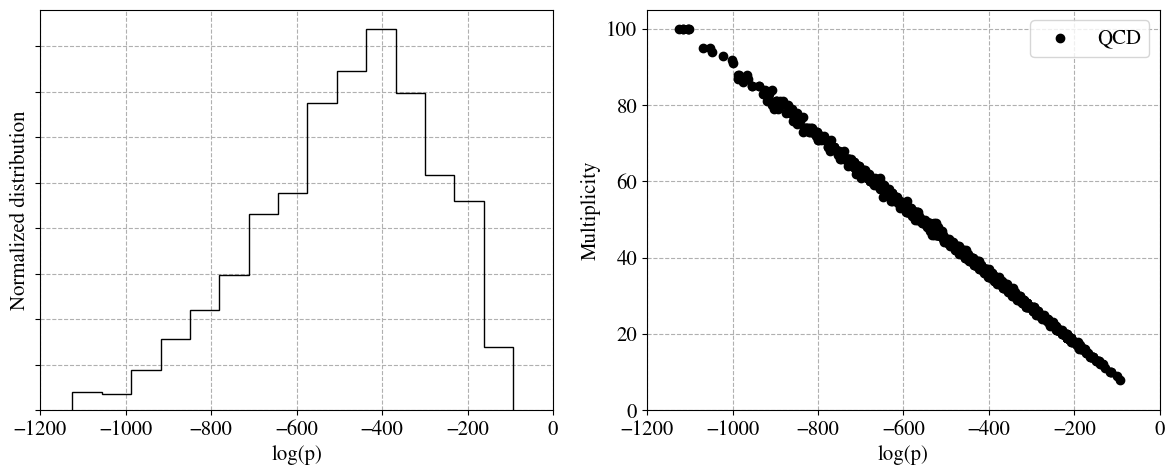

In [ ]:
fig1, ax1 = plt.subplots(1,2, figsize=(12,5), dpi=100)
ax1[0].hist(log_p, bins=15, color="black", density=True, histtype="step")
ax1[0].set_xlim(xmin, xmax)
ax1[0].set_xlabel(r"log(p)")
ax1[0].set_ylabel("Normalized distribution")
ax1[0].tick_params(labelleft=False)
ax1[0].grid(linestyle="--")
ax1[0].set_axisbelow(True)

ax1[1].scatter(log_p, counts, color="black", label="QCD")
ax1[1].set_xlim(xmin, xmax)
ax1[1].set_ylim(ymin, ymax)
ax1[1].set_xlabel(r"log(p)")
ax1[1].set_ylabel("Multiplicity")
ax1[1].grid(linestyle="--")
ax1[1].set_axisbelow(True)
ax1[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

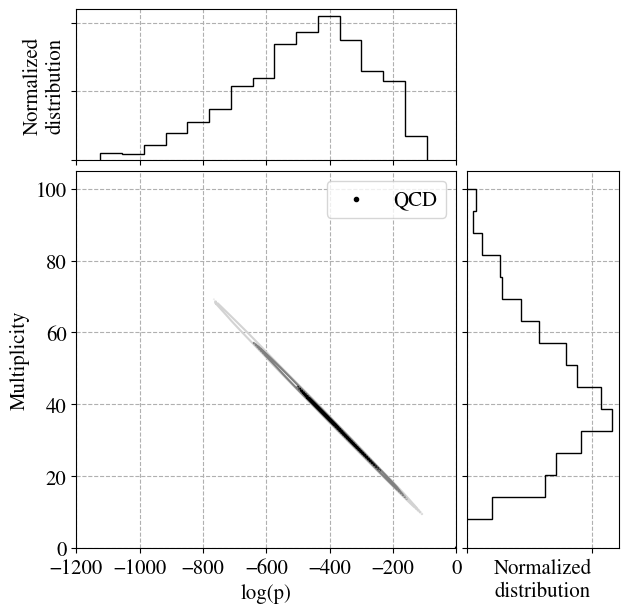

In [ ]:
fig = plt.figure(figsize=(7,7), dpi=100)
gs = GridSpec(
    2, 2,
    width_ratios=[2.5, 1],
    height_ratios=[1, 2.5],
    hspace=0.04,
    wspace=0.04
)

bins=15

# Achsen definieren
ax_histx = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1])


contours = ax_main.contour(xx, yy, zz, levels=levels, colors=["lightgrey", "grey", "black"])
#ax_main.scatter(log_p, counts, color="black", marker=".")
ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)
ax_main.set_xlabel(r"log(p)")
ax_main.set_ylabel("Multiplicity")
ax_main.grid(linestyle="--")
ax_main.set_axisbelow(True)
ax_main.scatter(1,0, color="black", label="QCD", marker=".")
ax_main.legend(loc="upper right")

# Histogramm oben (x-Achse)
ax_histx.hist(log_p, bins=bins, color="black", histtype="step", density=True)
ax_histx.set_xlim(ax_main.get_xlim())
ax_histx.set_ylabel("Normalized\ndistribution")
ax_histx.tick_params(labelbottom=False)
ax_histx.tick_params(labelleft=False)
ax_histx.grid(linestyle="--")
ax_histx.set_axisbelow(True)

# Histogramm rechts (y-Achse)
ax_histy.hist(counts, bins=bins, orientation="horizontal", color="black", histtype="step", density=True)
ax_histy.set_ylim(ax_main.get_ylim())
ax_histy.set_xlabel("Normalized\ndistribution")
ax_histy.tick_params(labelleft=False)
ax_histy.tick_params(labelbottom=False)
ax_histy.grid(linestyle="--")
ax_histy.set_axisbelow(True)

#plt.tight_layout()
plt.show()
